# Learning Curve: `batch_size=2` Training Run (200-epoch ceiling)

In [11]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

BLUE = '#2a78d6'    # train loss
ORANGE = '#eb6834'  # valid loss
GRAY = '#8a8a86'    # annotations, not a data series

In [12]:
out_dir = Path('benchmark_trainer_out_batch_small_200')
summary = pd.read_csv(out_dir / 'summary.csv').iloc[0]
epochs = pd.read_csv(out_dir / 'bs2_replay2_epochs.csv')

sec_per_epoch = summary['sec_per_epoch']
epochs['wall_time_min'] = (epochs['epoch'] + 1) * sec_per_epoch / 60

## Learning curve over wall time

Total loss (train + valid) on a log scale, since it spans several orders of magnitude.

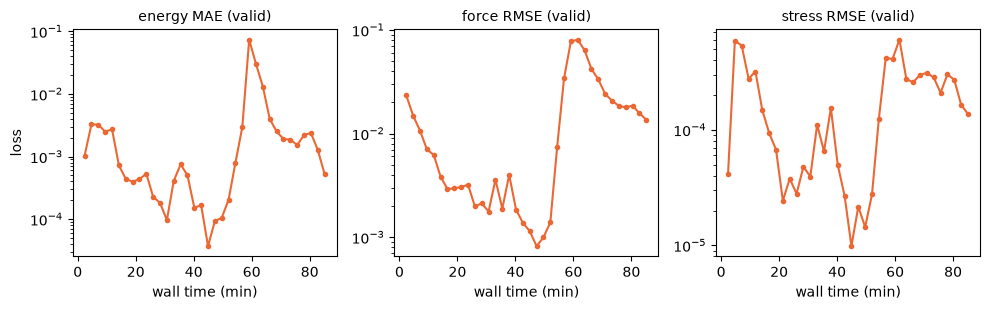

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.2), sharex=True)
cols = ['energy_mae_valid', 'force_rmse_valid', 'stress_rmse_valid']
titles = ['energy MAE (valid)', 'force RMSE (valid)', 'stress RMSE (valid)']
for ax, col, title in zip(axs, cols, titles):
    ax.plot(epochs['wall_time_min'], epochs[col], marker='o', markersize=3, color=ORANGE)
    ax.set_yscale('log')
    ax.set_xlabel('wall time (min)')
    ax.set_title(title, fontsize=10)
axs[0].set_ylabel('loss')
fig.tight_layout()